# Fraud Risk Analysis – Banking Transactions

## 1. Latar Belakang & Tujuan Analisis

Dalam industri perbankan, transaksi fraud merupakan salah satu risiko utama yang dapat
menyebabkan kerugian finansial serta menurunkan kepercayaan nasabah.

Dataset yang digunakan pada analisis ini berisi data transaksi perbankan yang telah
melalui proses technical cleaning dan business transformation pada tahap sebelumnya.
Data tersebut telah dimuat ke dalam PostgreSQL dan disiapkan dalam bentuk tabel
`transactions_analytics`.

Tujuan dari analisis ini adalah untuk:
- Mengidentifikasi pola transaksi yang berkaitan dengan fraud
- Mengeksplorasi karakteristik transaksi berisiko tinggi
- Menyediakan dasar analisis yang dapat digunakan untuk pengambilan keputusan bisnis

## 2. Sumber Data & Ruang Lingkup

Analisis ini menggunakan data transaksi yang bersumber dari file CSV
yang telah diproses dan dimuat ke PostgreSQL.

Sumber tabel:
- Database: `banking_db`
- Table: `transactions_analytics`

Ruang lingkup data:
- Jumlah transaksi: 200.000 baris
- Periode waktu: Januari 2025
- Label fraud tersedia pada kolom `is_fraud`

## 3. Import Libraries

In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Konfigurasi visual
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 4. Connect to Database & Load Data

In [3]:
conn = psycopg2.connect(
    host="127.0.0.1",
    port=5433,
    dbname="banking_db",
    user="postgres",
    password="postgres"
)

query = "SELECT * FROM transactions_analytics;"
df = pd.read_sql(query, conn)

conn.close()

df.head()

,customer_id,gender,age,account_type,state,city,transaction_id,transaction_date,transaction_time,transaction_month,transaction_hour,transaction_amount,account_balance,merchant_category,transaction_type,device_type,is_fraud
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Male,60,Savings,Kerala,Thiruvananthapuram,4fa3208f-9e23-42dc-b330-844829d0c12c,2025-01-23,16:04:07,2025-01-01 00:00:00+00:00,16.0,32415.45,74557.27,Restaurant,Transfer,POS,0
1,7c14ad51-781a-4db9-b7bd-67439c175262,Female,51,Business,Maharashtra,Nashik,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,2025-01-11,17:14:53,2025-01-01 00:00:00+00:00,17.0,43622.60,74622.66,Restaurant,Bill Payment,Desktop,0
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Male,20,Savings,Bihar,Bhagalpur,e41c55f9-c016-4ff3-872b-cae72467c75c,2025-01-25,03:09:52,2025-01-01 00:00:00+00:00,3.0,63062.56,66817.99,Groceries,Bill Payment,Desktop,0
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Female,57,Business,Tamil Nadu,Chennai,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,2025-01-19,12:27:02,2025-01-01 00:00:00+00:00,12.0,14000.72,58177.08,Entertainment,Debit,Mobile,0
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Female,43,Savings,Punjab,Amritsar,f8e6ac6f-81a1-4985-bf12-f60967d852ef,2025-01-30,18:30:46,2025-01-01 00:00:00+00:00,18.0,18335.16,16108.56,Entertainment,Transfer,Mobile,0


## 5. Pemeriksaan Struktur Data

Pada tahap ini dilakukan pemeriksaan awal untuk memahami struktur data,
tipe data setiap kolom, serta memastikan data siap digunakan untuk analisis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   customer_id         200000 non-null  object             
 1   gender              200000 non-null  object             
 2   age                 200000 non-null  int64              
 3   account_type        200000 non-null  object             
 4   state               200000 non-null  object             
 5   city                200000 non-null  object             
 6   transaction_id      200000 non-null  object             
 7   transaction_date    200000 non-null  object             
 8   transaction_time    200000 non-null  object             
 9   transaction_month   200000 non-null  datetime64[ns, UTC]
 10  transaction_hour    200000 non-null  float64            
 11  transaction_amount  200000 non-null  float64            
 12  account_balance 

In [5]:
df.describe()

,age,transaction_hour,transaction_amount,account_balance,is_fraud
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,11.490420,49538.015554,52437.988784,0.050440
std,15.288774,6.917094,28551.874004,27399.507128,0.218852
min,18.000000,0.000000,10.290000,5000.820000,0.000000
25%,31.000000,6.000000,24851.345000,28742.395000,0.000000
50%,44.000000,11.000000,49502.440000,52372.555000,0.000000
75%,57.000000,17.000000,74314.625000,76147.670000,0.000000
max,70.000000,23.000000,98999.980000,99999.950000,1.000000


## 6. Gambaran Umum Fraud

Bagian ini bertujuan untuk melihat distribusi transaksi fraud dan non-fraud
secara keseluruhan sebelum dilakukan analisis lebih mendalam.

In [6]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.94956
1    0.05044
Name: proportion, dtype: float64

## 7. Kerangka Pertanyaan Analisis Fraud

Setelah memahami proporsi fraud secara keseluruhan, analisis ini
difokuskan untuk menjawab delapan pertanyaan bisnis berikut:

1. Apakah tingkat fraud berbeda berdasarkan **jenis perangkat transaksi (device_type)**?
2. Apakah terdapat **kategori merchant** tertentu yang memiliki tingkat fraud lebih tinggi?
3. Bagaimana hubungan antara **nilai transaksi (transaction_amount)** dan kejadian fraud?
4. Apakah **jam transaksi** menunjukkan pola tertentu terhadap fraud?
5. Apakah tingkat fraud berbeda berdasarkan **jenis akun (account_type)**?
6. Apakah terdapat perbedaan risiko fraud berdasarkan **kelompok usia nasabah**?
7. Apakah fraud lebih sering terjadi pada **jenis transaksi tertentu** (debit, kredit, transfer)?
8. Apakah terdapat wilayah (**state / city**) dengan konsentrasi fraud yang lebih tinggi?

Pertanyaan-pertanyaan ini dirancang untuk membantu
mengidentifikasi faktor risiko utama transaksi fraud
dan memberikan dasar analisis bagi pengambilan keputusan bisnis.

### 7.1 Analisis Fraud berdasarkan Device Type

Analisis ini bertujuan untuk mengevaluasi apakah jenis perangkat yang digunakan
dalam transaksi memiliki perbedaan tingkat risiko fraud yang signifikan.

Visualisasi dan agregasi dilakukan dengan menghitung:
- total transaksi per device_type
- jumlah transaksi fraud
- fraud rate (fraud_count / total_transactions)

In [7]:
# Hitung jumlah transaksi dan fraud per device_type
device_summary = (
    df.groupby("device_type")
    .agg(
        total_transactions=("transaction_id", "count"),
        fraud_count=("is_fraud", "sum")
    )
    .reset_index()
)

# Hitung fraud rate
device_summary["fraud_rate"] = (
    device_summary["fraud_count"] / device_summary["total_transactions"]
)

device_summary.sort_values("fraud_rate", ascending=False)

,device_type,total_transactions,fraud_count,fraud_rate
1,Desktop,49872,2544,0.051011
3,POS,50111,2533,0.050548
0,ATM,50055,2518,0.050305
2,Mobile,49962,2493,0.049898


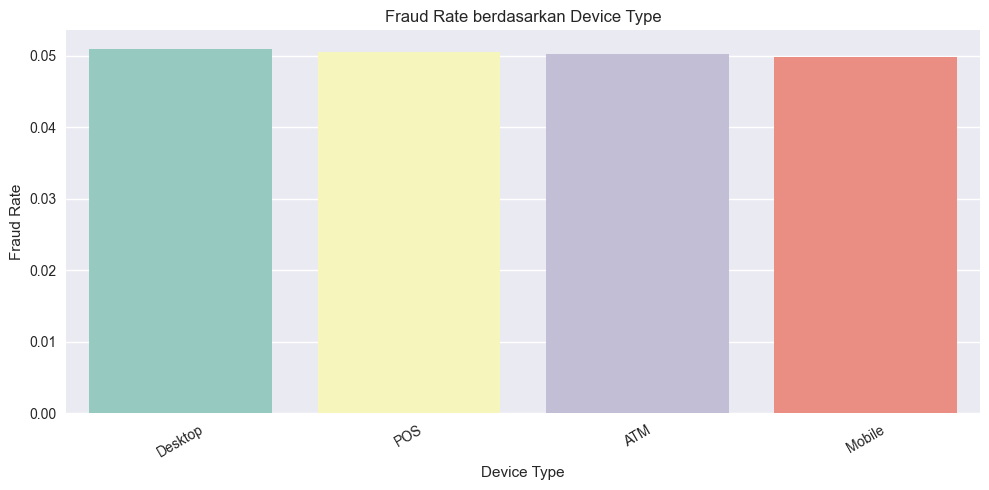

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=device_summary.sort_values("fraud_rate", ascending=False),
    x="device_type",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Hasil agregasi menunjukkan bahwa jumlah transaksi pada setiap device_type
relatif seimbang, masing-masing berada di kisaran ±50 ribu transaksi.
Kondisi ini memastikan bahwa perbandingan fraud rate antar device
tidak dipengaruhi oleh perbedaan ukuran sampel yang ekstrem.

Berdasarkan hasil perhitungan:
- Fraud rate tertinggi tercatat pada transaksi menggunakan **Desktop** (≈ 5,10%)
- Fraud rate terendah tercatat pada transaksi menggunakan **Mobile** (≈ 4,99%)
- Selisih maksimum fraud rate antar device hanya sekitar **0,11 percentage point**

Secara visual, grafik memperlihatkan bahwa tinggi batang fraud rate
antar device_type hampir sejajar, tanpa adanya lonjakan yang mencolok
pada satu jenis perangkat tertentu.

Temuan ini mengindikasikan bahwa, pada tingkat agregasi ini,
variabel **device_type** secara tunggal belum menunjukkan
pemisahan risiko fraud yang kuat.
Perbedaan yang muncul bersifat marginal dan relatif homogen
di seluruh jenis perangkat.

### 7.2 Analisis Fraud berdasarkan Merchant Category

Analisis ini bertujuan untuk mengevaluasi apakah kategori merchant
memiliki perbedaan tingkat fraud yang berarti pada level agregasi transaksi.

Proses agregasi dilakukan dengan menghitung:
- total transaksi per merchant_category
- jumlah transaksi fraud
- fraud rate (fraud_count / total_transactions)

In [9]:
# Agregasi fraud berdasarkan merchant category
fraud_by_merchant = (
    df.groupby("merchant_category")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_merchant["fraud_rate"] = (
    fraud_by_merchant["fraud_count"] / fraud_by_merchant["total_transactions"]
)

fraud_by_merchant = fraud_by_merchant.sort_values(
    by="fraud_rate", ascending=False
)

fraud_by_merchant

,merchant_category,total_transactions,fraud_count,fraud_rate
0,Clothing,33340,1734,0.052010
3,Groceries,33187,1722,0.051888
5,Restaurant,33525,1688,0.050350
1,Electronics,33409,1681,0.050316
4,Health,33118,1651,0.049852
2,Entertainment,33421,1612,0.048233


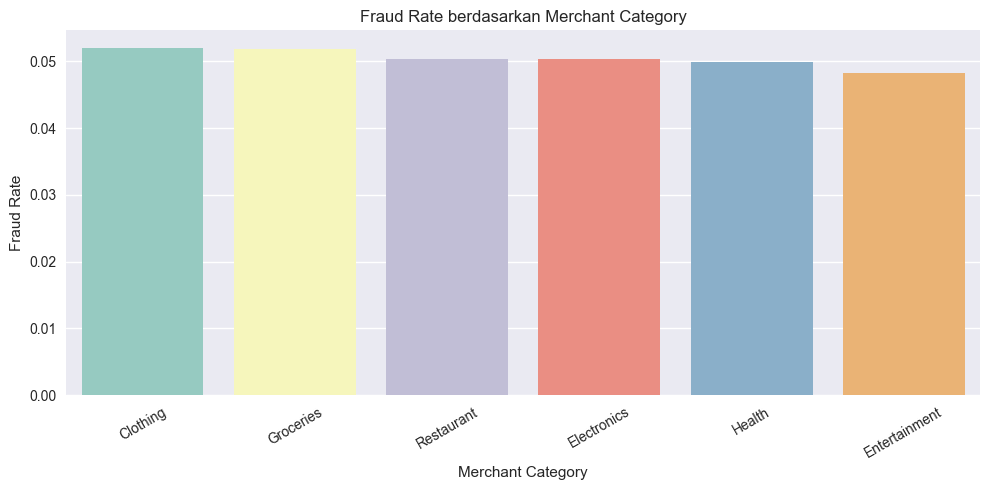

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=fraud_by_merchant,
    x="merchant_category",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Hasil agregasi menunjukkan bahwa jumlah transaksi pada setiap kategori merchant
relatif seimbang, berada pada kisaran ±33 ribu transaksi per kategori.
Kondisi ini memungkinkan perbandingan fraud rate yang relatif adil
tanpa bias akibat perbedaan volume transaksi yang ekstrem.

Berdasarkan hasil perhitungan fraud rate:
- **Clothing** memiliki fraud rate tertinggi (≈ 5,20%)
- **Groceries** berada sedikit di bawahnya (≈ 5,19%)
- **Restaurant** dan **Electronics** berada di kisaran ≈ 5,03%
- **Health** memiliki fraud rate ≈ 4,99%
- **Entertainment** memiliki fraud rate terendah (≈ 4,82%)

Rentang perbedaan fraud rate antar merchant category
berada pada kisaran sekitar **0,40 percentage point**,
dengan pola visual yang menunjukkan variasi bertahap
tanpa adanya kategori yang menjadi outlier ekstrem.

Visualisasi memperlihatkan bahwa sebagian besar kategori merchant
memiliki tingkat fraud yang saling berdekatan,
menunjukkan bahwa perbedaan risiko fraud antar kategori
pada tahap ini masih bersifat moderat dan gradual.

### 7.3 Analisis Fraud berdasarkan Nilai Transaksi (Transaction Amount)

Analisis ini bertujuan untuk mengevaluasi apakah **nilai transaksi**
memiliki hubungan yang signifikan dengan tingkat kejadian fraud
pada level agregasi transaksi.

Pendekatan analisis dilakukan melalui dua tahap utama:

1. **Perbandingan distribusi nilai transaksi**
   antara transaksi fraud dan non-fraud.
2. **Pengelompokan nilai transaksi ke dalam beberapa bucket**
   untuk membandingkan fraud rate antar kelompok nominal transaksi.


#### Distribusi Transaction Amount: Fraud vs Non-Fraud

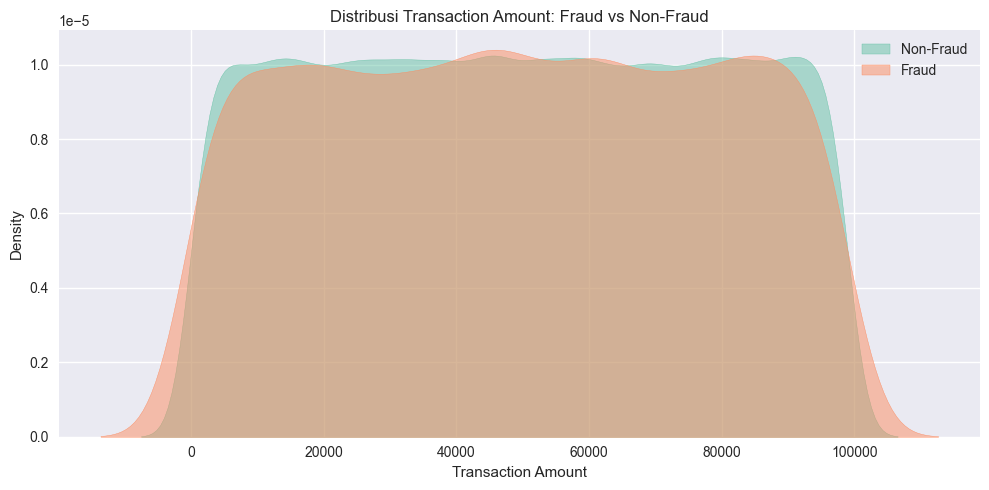

In [11]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=df[df["is_fraud"] == 0],
    x="transaction_amount",
    label="Non-Fraud",
    fill=True,
    alpha=0.5
)

sns.kdeplot(
    data=df[df["is_fraud"] == 1],
    x="transaction_amount",
    label="Fraud",
    fill=True,
    alpha=0.5
)

plt.title("Distribusi Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

#### Ringkasan Statistik Transaction Amount

In [12]:
df.groupby("is_fraud")["transaction_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,189912.0,49551.831380,28541.881772,10.29,24877.6850,49517.420,74326.8725,98999.98
1,10088.0,49277.925242,28739.518843,10.41,24420.0425,49162.945,74068.7175,98999.02


#### Fraud Rate berdasarkan Kelompok Nilai Transaksi

In [13]:
df["amount_bucket"] = pd.qcut(
    df["transaction_amount"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

amount_fraud = (
    df.groupby("amount_bucket")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

amount_fraud["fraud_rate"] = (
    amount_fraud["fraud_count"] / amount_fraud["total_transactions"]
)

amount_fraud

,amount_bucket,total_transactions,fraud_count,fraud_rate
0,Very Low,40000,2067,0.051675
1,Low,40000,1965,0.049125
2,Medium,40000,2025,0.050625
3,High,40000,2004,0.050100
4,Very High,40000,2027,0.050675


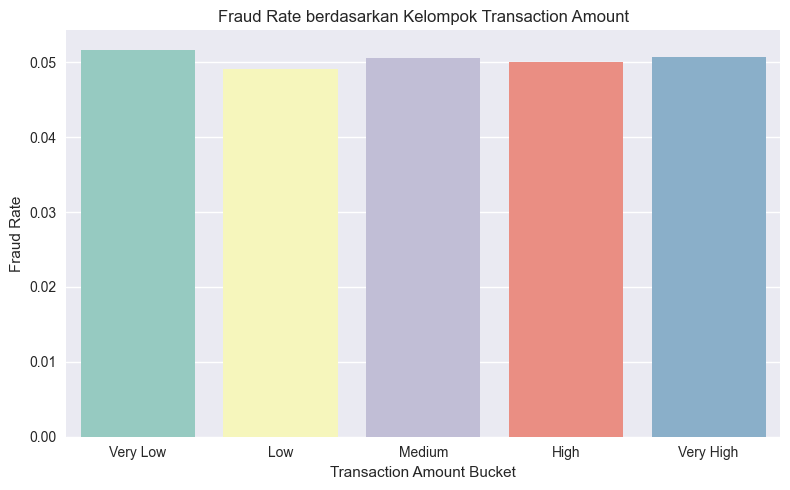

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=amount_fraud,
    x="amount_bucket",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Kelompok Transaction Amount")
plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

#### Distribusi Nilai Transaksi: Fraud vs Non-Fraud

Berdasarkan distribusi nilai transaksi fraud dan non-fraud,
visualisasi menunjukkan bahwa kedua distribusi
**saling tumpang tindih hampir di seluruh rentang nilai transaksi**.

Ringkasan statistik memperkuat temuan visual tersebut:

- Rata-rata nilai transaksi fraud dan non-fraud berada pada kisaran yang hampir identik.
- Median serta kuartil bawah dan atas menunjukkan perbedaan yang sangat kecil.
- Nilai maksimum transaksi pada kedua kelompok juga berada pada rentang yang serupa.

Temuan ini mengindikasikan bahwa, pada level agregasi,
**nilai nominal transaksi tidak menunjukkan perbedaan distribusi yang mencolok**
antara transaksi fraud dan non-fraud.

---

#### Fraud Rate berdasarkan Kelompok Nilai Transaksi

Hasil agregasi menunjukkan bahwa:

- Setiap bucket berisi jumlah transaksi yang relatif seimbang.
- Fraud rate pada masing-masing kelompok berada di kisaran **±5%**.
- Tidak terdapat pola peningkatan atau penurunan fraud rate yang konsisten
  seiring dengan meningkatnya nilai transaksi.

Rentang perbedaan fraud rate antar kelompok nilai transaksi
berada pada kisaran **±0,25–0,30 percentage point**,
menunjukkan variasi yang relatif kecil
tanpa adanya kelompok nominal transaksi yang menjadi outlier ekstrem.

Secara visual, grafik memperlihatkan bahwa
**risiko fraud tersebar relatif merata**
di seluruh rentang nilai transaksi yang diamati.


### 7.4 Analisis Fraud berdasarkan Jam Transaksi

Analisis ini bertujuan untuk mengevaluasi apakah waktu terjadinya transaksi
(dilihat dari jam transaksi dalam rentang 0–23)
memiliki keterkaitan dengan tingkat kejadian fraud
pada level agregasi transaksi.

Pendekatan analisis dilakukan melalui dua sudut pandang utama:

1. Distribusi jumlah transaksi pada setiap jam
2. Perbandingan fraud rate pada masing-masing jam transaksi

#### Distribusi Jumlah Transaksi per Jam

In [15]:
transactions_per_hour = (
    df.groupby("transaction_hour")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

transactions_per_hour["fraud_rate"] = (
    transactions_per_hour["fraud_count"] / transactions_per_hour["total_transactions"]
)

transactions_per_hour.head()

,transaction_hour,total_transactions,fraud_count,fraud_rate
0,0.0,8399,447,0.053221
1,1.0,8266,419,0.050690
2,2.0,8312,425,0.051131
3,3.0,8329,436,0.052347
4,4.0,8319,438,0.052651


#### Visualisasi Jumlah Transaksi per Jam

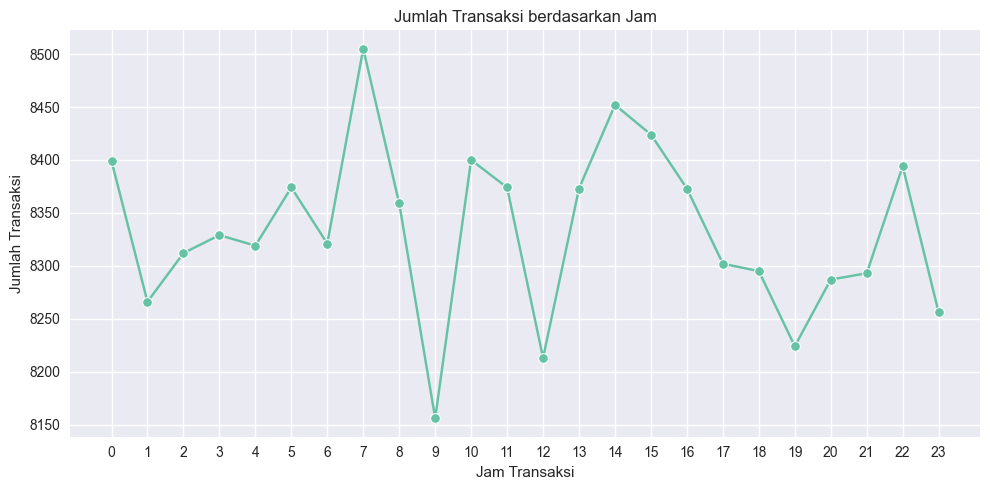

In [16]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=transactions_per_hour,
    x="transaction_hour",
    y="total_transactions",
    marker="o"
)

plt.title("Jumlah Transaksi berdasarkan Jam")
plt.xlabel("Jam Transaksi")
plt.ylabel("Jumlah Transaksi")

plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#### Visualisasi Fraud Rate per Jam Transaksi

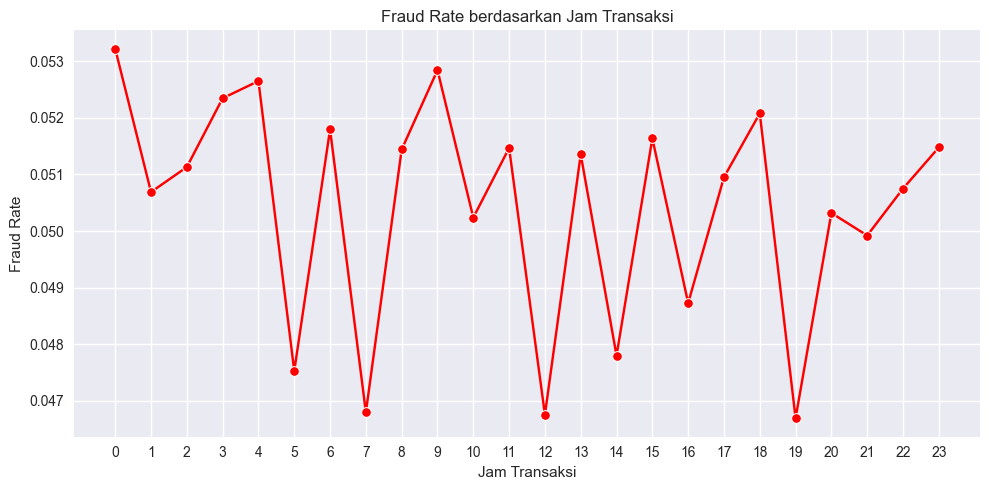

In [17]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=transactions_per_hour,
    x="transaction_hour",
    y="fraud_rate",
    marker="o",
    color="red"
)

plt.title("Fraud Rate berdasarkan Jam Transaksi")
plt.xlabel("Jam Transaksi")
plt.ylabel("Fraud Rate")

plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#### Alternatif Visualisasi: Bar Chart Fraud Rate

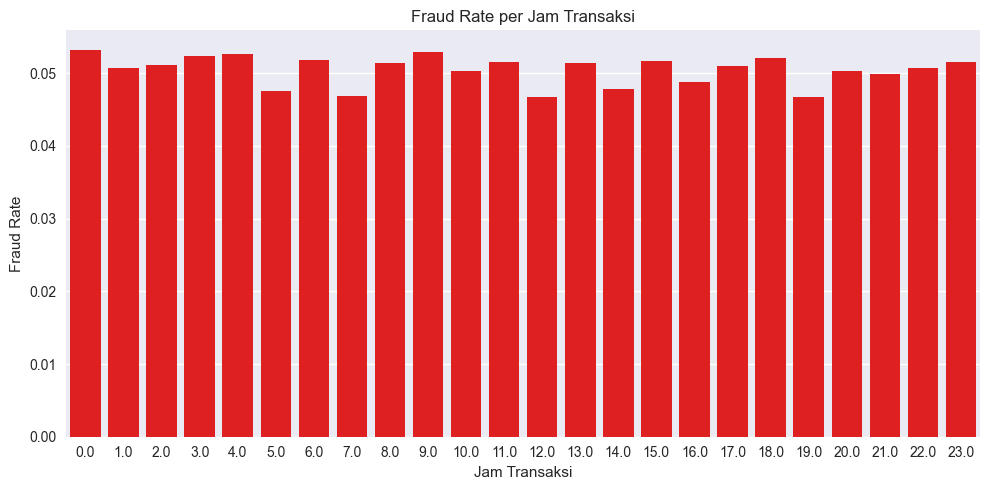

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=transactions_per_hour,
    x="transaction_hour",
    y="fraud_rate",
    color='red'
)

plt.title("Fraud Rate per Jam Transaksi")
plt.xlabel("Jam Transaksi")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

#### Distribusi Jumlah Transaksi per Jam

Visualisasi jumlah transaksi per jam menunjukkan bahwa:
- Volume transaksi relatif **merata sepanjang hari**
- Tidak terdapat lonjakan ekstrem pada jam tertentu
- Setiap jam mencatat sekitar **8.100 – 8.500 transaksi**

Kondisi ini penting karena memastikan bahwa
perbandingan fraud rate antar jam
tidak didominasi oleh perbedaan volume transaksi yang ekstrem.

---

#### Fraud Rate per Jam Transaksi

Hasil agregasi fraud rate berdasarkan jam transaksi menunjukkan bahwa:

- Fraud rate pada hampir seluruh jam
  berada di kisaran **±4,7% – 5,3%**
- Jam dengan fraud rate relatif lebih tinggi
  tetap berada dalam rentang yang sempit
- Tidak terdapat jam transaksi dengan fraud rate
  yang menyimpang secara signifikan dari pola umum

Berdasarkan tabel agregasi:
- Jam dengan fraud rate tertinggi berada di kisaran sekitar **5,3%**
- Jam dengan fraud rate terendah berada di kisaran sekitar **4,7%**
- Rentang selisih fraud rate antar jam berada di bawah **0,7 percentage point**

---

#### Ringkasan Pola Temporal

Secara visual dan numerik, analisis menunjukkan bahwa:
- Pola fraud tersebar relatif merata di seluruh jam transaksi
- Tidak terlihat konsentrasi risiko fraud yang tajam
  pada jam tertentu (misalnya dini hari atau jam kerja)
- Variasi fraud rate antar jam bersifat **fluktuatif ringan**
  dan tidak membentuk tren temporal yang kuat

Dengan demikian, pada level agregasi jam transaksi,
waktu transaksi tidak menunjukkan perbedaan risiko fraud
yang ekstrem atau dominan pada jam tertentu.

### 7.5 Analisis Fraud berdasarkan Jenis Akun (Account Type)

Analisis ini bertujuan untuk mengevaluasi apakah
jenis akun nasabah (Business, Checking, dan Savings)
menunjukkan perbedaan tingkat risiko fraud
pada level agregasi transaksi.

Pendekatan analisis dilakukan melalui dua tahap utama:

1. Perbandingan jumlah transaksi pada setiap jenis akun
2. Evaluasi fraud rate untuk masing-masing account type

In [19]:
# Agregasi Transaksi dan Fraud per Account Type
fraud_by_account = (
    df.groupby("account_type")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_account["fraud_rate"] = (
    fraud_by_account["fraud_count"] / fraud_by_account["total_transactions"]
)

fraud_by_account.sort_values("fraud_rate", ascending=False)

,account_type,total_transactions,fraud_count,fraud_rate
0,Business,66483,3436,0.051682
2,Savings,66593,3349,0.050291
1,Checking,66924,3303,0.049354


#### Visualisasi Jumlah Transaksi per Account Type

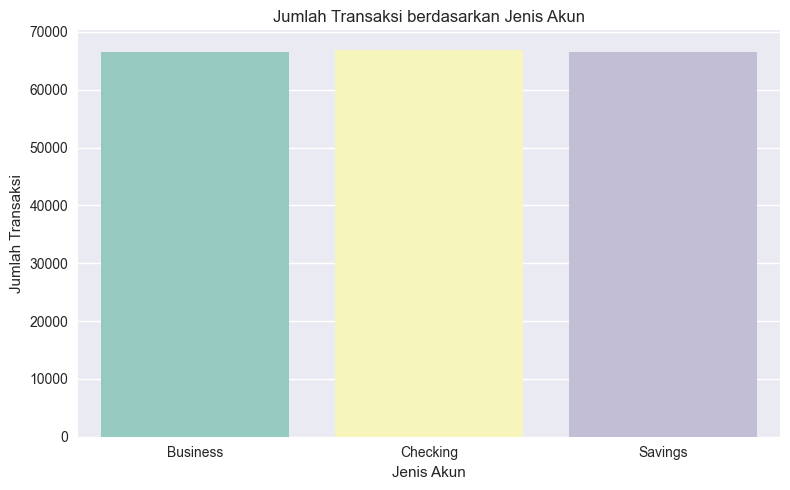

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fraud_by_account,
    x="account_type",
    y="total_transactions",
    palette='Set3'
)

plt.title("Jumlah Transaksi berdasarkan Jenis Akun")
plt.xlabel("Jenis Akun")
plt.ylabel("Jumlah Transaksi")

plt.tight_layout()
plt.show()

#### Visualisasi Fraud Rate per Account Type

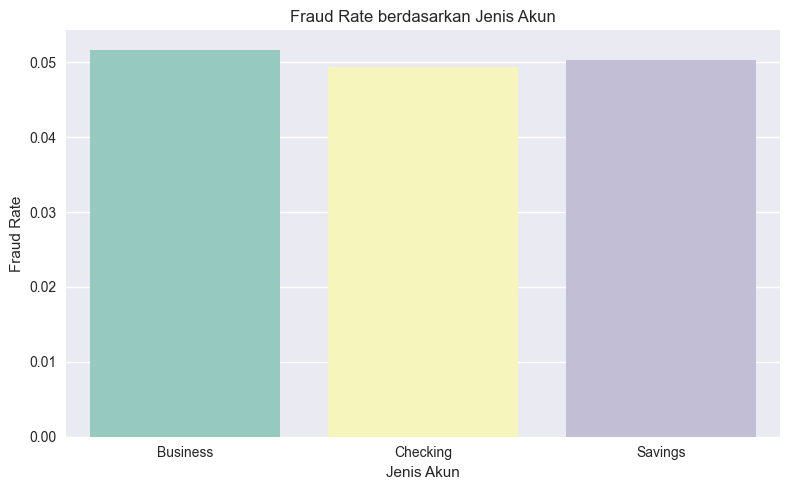

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fraud_by_account,
    x="account_type",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Jenis Akun")
plt.xlabel("Jenis Akun")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

#### Distribusi Jumlah Transaksi per Jenis Akun

Visualisasi jumlah transaksi berdasarkan jenis akun menunjukkan bahwa:
- Ketiga jenis akun memiliki volume transaksi yang **relatif seimbang**
- Setiap kategori berada pada kisaran **±66 ribu transaksi**
- Tidak terdapat jenis akun yang mendominasi secara ekstrem
  dalam jumlah transaksi

Kondisi ini memungkinkan perbandingan fraud rate antar jenis akun
dilakukan secara lebih adil,
karena tidak dipengaruhi oleh perbedaan volume transaksi yang signifikan.

---

#### Fraud Rate per Jenis Akun

Hasil agregasi fraud rate berdasarkan jenis akun menunjukkan bahwa:

- **Business account** memiliki fraud rate tertinggi
  dengan nilai sekitar **5,17%**
- **Savings account** berada sedikit di bawahnya
  dengan fraud rate sekitar **5,03%**
- **Checking account** memiliki fraud rate terendah
  dengan nilai sekitar **4,94%**

Rentang perbedaan fraud rate antar jenis akun
berada pada kisaran sekitar **0,23 percentage point**.

---

#### Ringkasan Pola Risiko berdasarkan Jenis Akun

Berdasarkan hasil visualisasi dan agregasi data:
- Perbedaan fraud rate antar jenis akun
  terlihat **relatif kecil namun konsisten**
- Tidak terdapat jenis akun yang menunjukkan lonjakan risiko fraud
  yang ekstrem dibanding kategori lainnya
- Pola risiko fraud antar jenis akun
  bersifat **gradual**, bukan diskrit atau tajam

Dengan demikian, pada level agregasi transaksi,
jenis akun menunjukkan variasi risiko fraud yang moderat
tanpa adanya kategori yang menjadi outlier ekstrem.

### 7.6 Analisis Fraud berdasarkan Kelompok Usia Nasabah

Analisis ini bertujuan untuk mengevaluasi apakah terdapat perbedaan
tingkat fraud antar kelompok usia nasabah,
serta memahami bagaimana distribusi volume transaksi
dan fraud rate tersebar pada masing-masing kelompok umur.

Kelompok usia dibagi menjadi enam kategori:
`<25`, `25–34`, `35–44`, `45–54`, `55–64`, dan `65+`.

In [22]:
# Definisi kelompok usia
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ["<25", "25–34", "35–44", "45–54", "55–64", "65+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)

df[["age", "age_group"]].head()

,age,age_group
0,60,55–64
1,51,45–54
2,20,<25
3,57,55–64
4,43,35–44


In [23]:
# Agregasi Transaksi dan Fraud per Kelompok Usia
fraud_by_age = (
    df.groupby("age_group")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_age["fraud_rate"] = (
    fraud_by_age["fraud_count"] / fraud_by_age["total_transactions"]
)

fraud_by_age

,age_group,total_transactions,fraud_count,fraud_rate
0,<25,26217,1353,0.051608
1,25–34,37865,1874,0.049492
2,35–44,37960,1960,0.051633
3,45–54,37510,1883,0.050200
4,55–64,37770,1930,0.051099
5,65+,22678,1088,0.047976


#### Visualisasi Jumlah Transaksi per Kelompok Usia

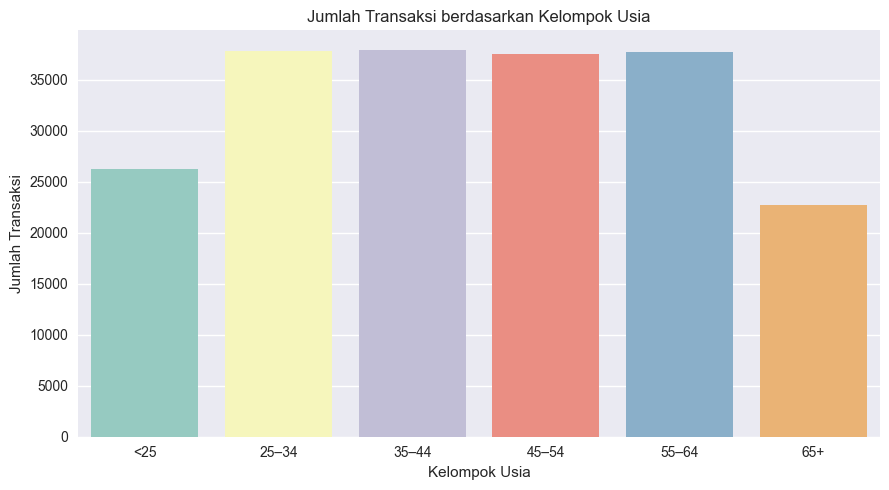

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=fraud_by_age,
    x="age_group",
    y="total_transactions",
    palette='Set3'
)

plt.title("Jumlah Transaksi berdasarkan Kelompok Usia")
plt.xlabel("Kelompok Usia")
plt.ylabel("Jumlah Transaksi")

plt.tight_layout()
plt.show()

#### Visualisasi Fraud Rate per Kelompok Usia

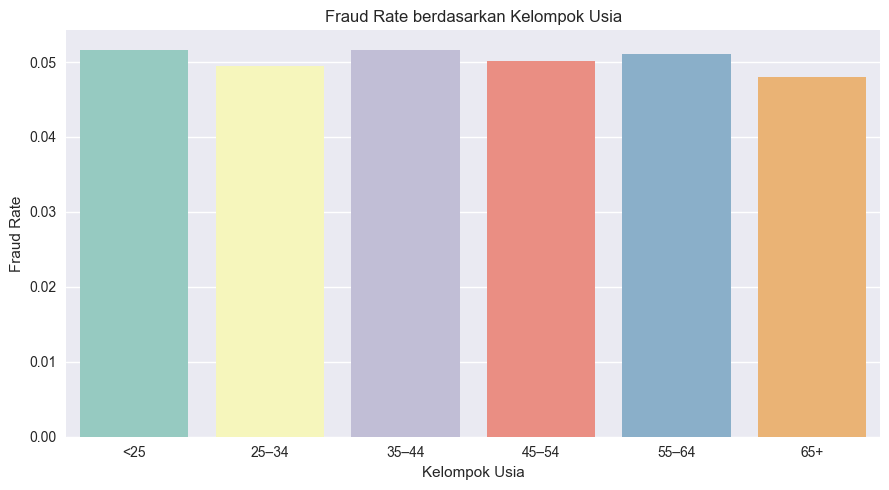

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=fraud_by_age,
    x="age_group",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Kelompok Usia")
plt.xlabel("Kelompok Usia")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

#### Distribusi Jumlah Transaksi

Berdasarkan visualisasi jumlah transaksi:
- Kelompok usia **25–34**, **35–44**, **45–54**, dan **55–64**
  memiliki volume transaksi yang relatif seimbang,
  masing-masing berada di kisaran **37–38 ribu transaksi**.
- Kelompok usia **<25** mencatat volume transaksi yang lebih rendah
  (≈ **26 ribu transaksi**).
- Kelompok usia **65+** memiliki volume transaksi paling sedikit
  (≈ **22,7 ribu transaksi**).

Distribusi ini menunjukkan bahwa sebagian besar aktivitas transaksi
berasal dari kelompok usia produktif hingga pra-pensiun,
sementara kelompok usia paling muda dan paling tua
memiliki kontribusi volume yang lebih kecil.

---

#### Perbandingan Fraud Rate antar Kelompok Usia

Hasil agregasi fraud rate menunjukkan bahwa:
- Fraud rate tertinggi terdapat pada kelompok usia **35–44**
  dengan nilai sekitar **5,16%**.
- Kelompok usia **<25** dan **55–64**
  juga menunjukkan fraud rate yang relatif tinggi
  (≈ **5,16%** dan **5,11%**).
- Kelompok usia **45–54** berada pada kisaran menengah
  dengan fraud rate ≈ **5,02%**.
- Kelompok usia **25–34** memiliki fraud rate ≈ **4,95%**.
- Kelompok usia **65+** menunjukkan fraud rate terendah
  dengan nilai sekitar **4,80%**.

Rentang perbedaan fraud rate antar kelompok usia
berada pada kisaran **±0,35 percentage point**,
tanpa adanya lonjakan ekstrem pada kelompok usia tertentu.

---

#### Ringkasan Pola yang Teramati

Secara visual dan numerik:
- Tidak terdapat hubungan linier yang jelas
  antara bertambahnya usia dan peningkatan fraud rate.
- Kelompok usia dengan volume transaksi tinggi
  tidak selalu memiliki fraud rate tertinggi.
- Variasi fraud antar kelompok usia
  bersifat **moderat dan gradual**, bukan ekstrem.

Temuan ini menunjukkan bahwa,
pada level agregasi usia,
risiko fraud relatif tersebar di berbagai kelompok umur,
dengan perbedaan tingkat risiko yang tidak terlalu tajam.

### 7.7 Analisis Fraud berdasarkan Jenis Transaksi

Analisis ini bertujuan untuk mengevaluasi apakah **jenis transaksi**
memiliki perbedaan tingkat risiko fraud
pada level agregasi transaksi.

Jenis transaksi yang dianalisis meliputi:
Bill Payment, Credit, Debit, Transfer, dan Withdrawal.

#### Metodologi Analisis
Proses agregasi dilakukan dengan menghitung:
- total transaksi untuk setiap `transaction_type`
- jumlah transaksi fraud
- fraud rate (fraud_count / total_transactions)

In [26]:
# Agregasi Transaksi dan Fraud per Jenis Transaksi
fraud_by_transaction_type = (
    df.groupby("transaction_type")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_transaction_type["fraud_rate"] = (
    fraud_by_transaction_type["fraud_count"] / fraud_by_transaction_type["total_transactions"]
)

fraud_by_transaction_type

,transaction_type,total_transactions,fraud_count,fraud_rate
0,Bill Payment,40040,1973,0.049276
1,Credit,40180,2048,0.050971
2,Debit,40050,2033,0.050762
3,Transfer,39953,2073,0.051886
4,Withdrawal,39777,1961,0.049300


#### Visualisasi Jumlah Transaksi per Jenis Transaksi

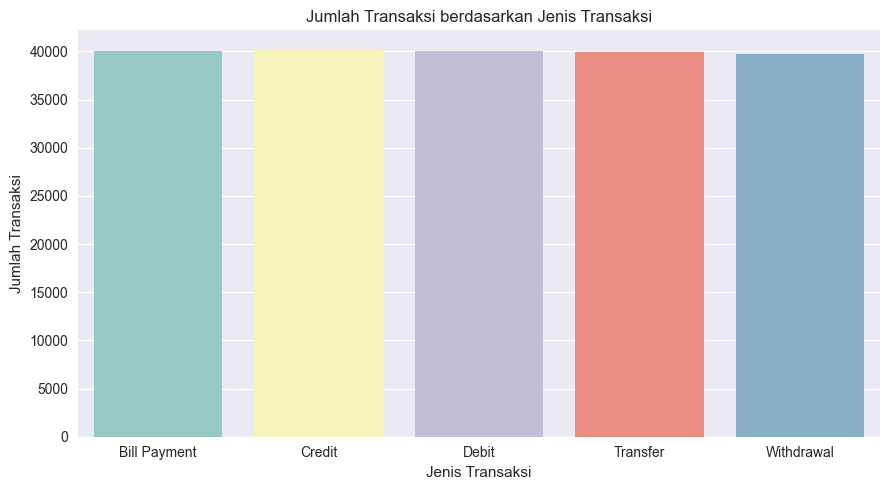

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=fraud_by_transaction_type,
    x="transaction_type",
    y="total_transactions",
    palette='Set3'
)

plt.title("Jumlah Transaksi berdasarkan Jenis Transaksi")
plt.xlabel("Jenis Transaksi")
plt.ylabel("Jumlah Transaksi")

plt.tight_layout()
plt.show()

#### Visualisasi Fraud Rate per Jenis Transaksi

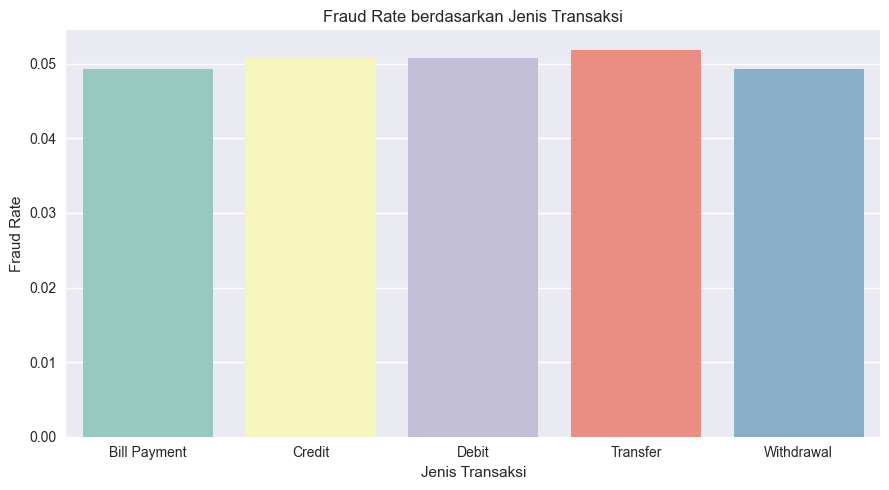

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=fraud_by_transaction_type,
    x="transaction_type",
    y="fraud_rate",
    palette='Set3'
)

plt.title("Fraud Rate berdasarkan Jenis Transaksi")
plt.xlabel("Jenis Transaksi")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

Jumlah transaksi pada setiap jenis transaksi
relatif seimbang, berada pada kisaran **±40 ribu transaksi**.
Kondisi ini memungkinkan perbandingan fraud rate
tanpa bias akibat perbedaan volume transaksi yang signifikan.

---

#### Hasil Agregasi Fraud Rate
Berdasarkan perhitungan fraud rate, diperoleh hasil sebagai berikut:

- **Transfer** memiliki fraud rate tertinggi (≈ **5,19%**)
- **Credit** dan **Debit** berada pada kisaran yang sangat berdekatan (≈ **5,07% – 5,10%**)
- **Withdrawal** memiliki fraud rate ≈ **4,93%**
- **Bill Payment** menunjukkan fraud rate terendah (≈ **4,93%**)

Rentang perbedaan fraud rate antar jenis transaksi
berada pada kisaran sekitar **0,26 percentage point**.

---

#### Interpretasi Visual
Visualisasi memperlihatkan bahwa:
- Tidak terdapat lonjakan ekstrem fraud rate pada jenis transaksi tertentu
- Perbedaan antar kategori bersifat **bertahap dan moderat**
- Seluruh jenis transaksi berada di sekitar baseline fraud rate ≈ **5%**

Pola ini menunjukkan bahwa,
pada level agregasi,
**jenis transaksi belum menjadi faktor pembeda risiko fraud yang kuat secara tunggal**,
melainkan kemungkinan berinteraksi dengan variabel lain
seperti waktu transaksi, lokasi, atau karakteristik akun.

### 7.8 Analisis Fraud berdasarkan Wilayah (State dan City)

Analisis ini bertujuan untuk mengidentifikasi apakah terdapat wilayah geografis
(state dan city) yang menunjukkan tingkat fraud lebih tinggi
dibandingkan wilayah lainnya pada level agregasi transaksi.

Pendekatan analisis dilakukan dengan:
- Menghitung total transaksi per state dan city
- Menghitung jumlah transaksi fraud
- Menghitung fraud rate (fraud_count / total_transactions)
- Memfokuskan analisis pada **Top 10 fraud rate tertinggi**
  untuk menghindari noise dari wilayah dengan volume transaksi sangat kecil


#### Fraud berdasarkan State

In [29]:
# Agregasi Fraud per State
fraud_by_state = (
    df.groupby("state")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_state["fraud_rate"] = (
    fraud_by_state["fraud_count"] / fraud_by_state["total_transactions"]
)

fraud_by_state.sort_values("fraud_rate", ascending=False).head(10)

,state,total_transactions,fraud_count,fraud_rate
28,Tamil Nadu,5841,328,0.056155
16,Lakshadweep,5954,332,0.055761
27,Sikkim,5793,312,0.053858
32,Uttarakhand,5985,319,0.053300
33,West Bengal,5851,311,0.053153
17,Madhya Pradesh,5928,315,0.053138
21,Mizoram,5892,312,0.052953
29,Telangana,5952,315,0.052923
30,Tripura,5869,308,0.052479
14,Karnataka,5775,303,0.052468


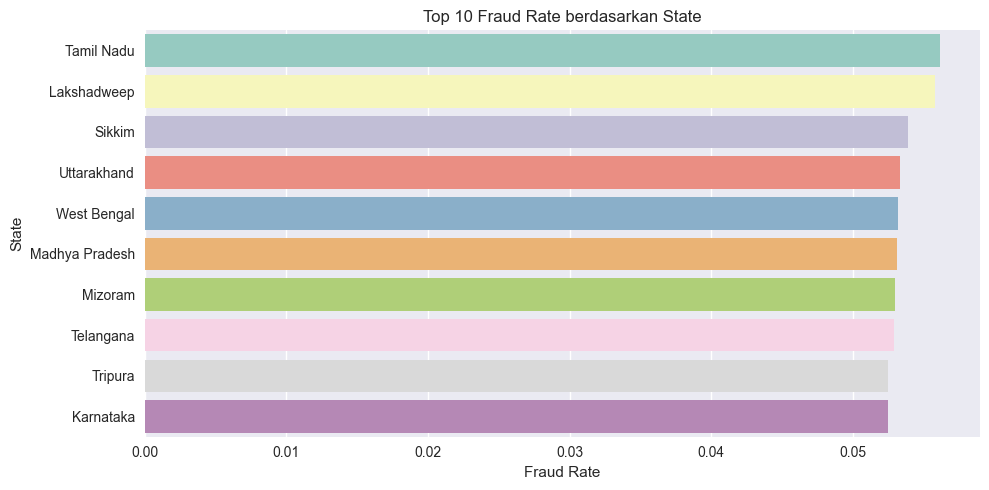

In [30]:
# Visualisasi Fraud Rate per State (Top 10)
top_state = fraud_by_state.sort_values("fraud_rate", ascending=False).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_state,
    x="fraud_rate",
    y="state",
    palette='Set3'
)

plt.title("Top 10 Fraud Rate berdasarkan State")
plt.xlabel("Fraud Rate")
plt.ylabel("State")

plt.tight_layout()
plt.show()


#### Fraud berdasarkan City

In [31]:
# Agregasi Fraud per City
fraud_by_city = (
    df.groupby("city")
      .agg(
          total_transactions=("transaction_id", "count"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

fraud_by_city["fraud_rate"] = (
    fraud_by_city["fraud_count"] / fraud_by_city["total_transactions"]
)

fraud_by_city.sort_values("fraud_rate", ascending=False).head(10)

,city,total_transactions,fraud_count,fraud_rate
45,Haridwar,1161,78,0.067183
11,Belgaum,1156,75,0.064879
60,Jorethang,1481,96,0.064821
46,Hazaribagh,1147,73,0.063644
102,New Delhi,1150,73,0.063478
24,Coimbatore,1167,73,0.062554
42,Guwahati,1122,70,0.062389
3,Aizawl,1434,88,0.061367
131,Trichy,1147,70,0.061029
69,Khammam,1204,72,0.059801


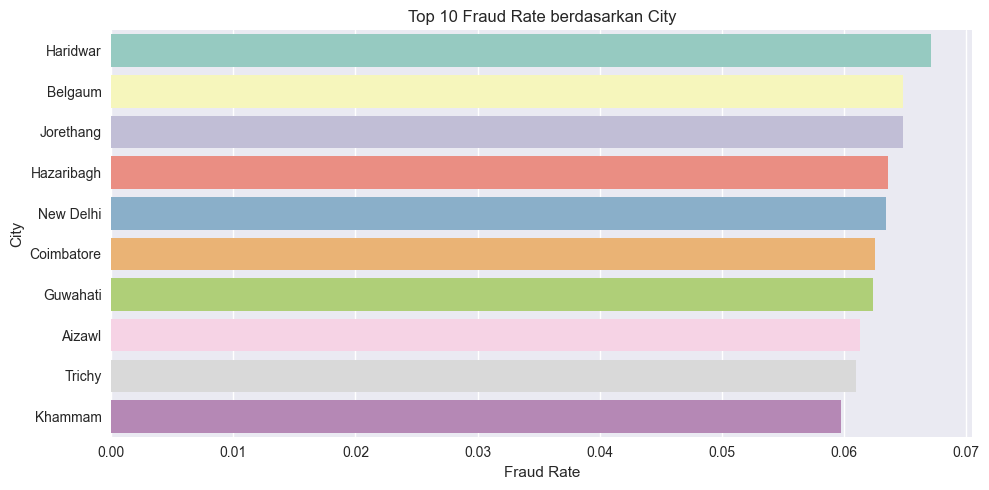

In [32]:
# Visualisasi Fraud Rate per City (Top 10)
top_city = fraud_by_city.sort_values("fraud_rate", ascending=False).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_city,
    x="fraud_rate",
    y="city",
    palette='Set3'
)

plt.title("Top 10 Fraud Rate berdasarkan City")
plt.xlabel("Fraud Rate")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Analisis berdasarkan State

Hasil agregasi menunjukkan bahwa fraud rate antar state
berada pada rentang yang relatif sempit, yaitu sekitar **5,25%–5,62%**.

State dengan fraud rate tertinggi adalah:
- **Tamil Nadu** (≈ **5,62%**)
- **Lakshadweep** (≈ **5,58%**)
- **Sikkim** (≈ **5,39%**)

Sementara state lain dalam Top 10 seperti:
**Uttarakhand, West Bengal, Madhya Pradesh, Mizoram, Telangana, Tripura,**
dan **Karnataka** berada pada kisaran **5,24%–5,33%**.

Perbedaan fraud rate antara state tertinggi dan terendah
dalam Top 10 hanya sekitar **0,38 percentage point**,
menunjukkan bahwa variasi risiko fraud antar state
bersifat moderat dan tidak menunjukkan lonjakan ekstrem
pada satu wilayah tertentu.

---

### Analisis berdasarkan City

Pada level city, variasi fraud rate terlihat lebih lebar
dibandingkan level state.

City dengan fraud rate tertinggi adalah:
- **Haridwar** (≈ **6,72%**)
- **Belgaum** (≈ **6,49%**)
- **Jorethang** (≈ **6,48%**)

City lain seperti:
**Hazaribagh, New Delhi, Coimbatore, Guwahati, Aizawl, Trichy,**
dan **Khammam** berada pada kisaran **5,98%–6,36%**.

Rentang perbedaan fraud rate antar city dalam Top 10
mencapai sekitar **0,92 percentage point**,
lebih besar dibandingkan variasi antar state.

Namun demikian, seluruh city dalam Top 10
memiliki volume transaksi yang relatif sebanding
(±1.100–1.500 transaksi),
sehingga perbedaan fraud rate ini
tidak semata-mata disebabkan oleh distorsi volume data.

---

### Ringkasan Temuan Wilayah

Secara keseluruhan:
- Variasi fraud rate pada level **state** bersifat sempit dan stabil
- Variasi fraud rate pada level **city** lebih terlihat,
  meskipun tetap berada dalam rentang yang relatif terkendali
- Tidak terdapat wilayah dengan fraud rate yang jauh menyimpang
  dari pola umum sistem transaksi

Temuan ini menunjukkan bahwa faktor geografis
memberikan diferensiasi risiko fraud yang lebih jelas
pada level granular (city) dibandingkan level agregat (state),
namun tetap tanpa indikasi konsentrasi fraud yang ekstrem.

## 8. Ringkasan Temuan Analisis Fraud

Berdasarkan delapan analisis yang telah dilakukan pada berbagai dimensi
(transaksi, nasabah, kanal, waktu, dan wilayah),
dapat disusun gambaran menyeluruh mengenai pola fraud
pada data transaksi perbankan ini.

Secara umum, **tingkat fraud berada pada kisaran yang relatif homogen**
di hampir seluruh dimensi yang dianalisis,
dengan fraud rate konsisten di sekitar **±5%**.
Tidak ditemukan satu faktor tunggal
yang menunjukkan lonjakan risiko fraud yang ekstrem
atau menyimpang jauh dari pola umum.

### Pola Kanal dan Perilaku Transaksi

Analisis berdasarkan **device type** dan **jenis transaksi**
menunjukkan bahwa fraud tidak terkonsentrasi
pada satu kanal atau mekanisme transaksi tertentu.
Perbedaan fraud rate antar device (Desktop, POS, ATM, Mobile)
serta antar jenis transaksi (Bill Payment, Credit, Debit, Transfer, Withdrawal)
bersifat **gradual dan sempit**,
tanpa adanya kanal yang secara dominan lebih berisiko.

Hal ini mengindikasikan bahwa
fraud pada data ini tidak bersifat channel-specific,
melainkan tersebar merata di seluruh sarana transaksi.

### Nilai Transaksi dan Dimensi Waktu

Distribusi **nilai transaksi** antara transaksi fraud dan non-fraud
menunjukkan tumpang tindih yang hampir penuh
di seluruh rentang nominal transaksi.
Baik analisis distribusi kontinu
maupun pengelompokan ke dalam bucket nilai transaksi
menunjukkan bahwa fraud rate relatif stabil
dari transaksi bernilai sangat rendah hingga sangat tinggi.

Demikian pula pada dimensi **jam transaksi**,
fraud terjadi sepanjang 24 jam
dengan variasi kecil antar jam.
Meskipun terdapat fluktuasi minor pada jam tertentu,
tidak ditemukan periode waktu
yang secara konsisten menunjukkan konsentrasi fraud yang tajam.

### Karakteristik Nasabah

Pada dimensi **jenis akun** dan **kelompok usia**,
fraud rate juga menunjukkan perbedaan yang terbatas.
Akun Business, Checking, dan Savings
memiliki tingkat fraud yang berdekatan,
demikian pula antar kelompok usia,
di mana variasi fraud rate antar kelompok
berada dalam rentang yang relatif sempit.

Temuan ini menunjukkan bahwa
profil nasabah pada level agregasi
belum menunjukkan segmentasi risiko yang kontras.

### Dimensi Geografis

Berbeda dengan dimensi lainnya,
analisis geografis pada level **state** dan **city**
menunjukkan variasi yang relatif lebih menonjol.
Beberapa wilayah muncul secara konsisten
dalam daftar dengan fraud rate tertinggi,
meskipun tetap berada dalam rentang moderat.

Pola ini mengindikasikan bahwa
dimensi geografis berpotensi menjadi sumber variasi risiko
yang lebih informatif dibandingkan dimensi lainnya,
terutama ketika dianalisis pada granularitas yang lebih halus.

### Kesimpulan Sementara

Secara keseluruhan,
data menunjukkan bahwa risiko fraud
bersifat **tersebar dan tidak terpusat**
pada satu dimensi tunggal.
Sebagian besar faktor yang dianalisis
menunjukkan perbedaan risiko yang bertahap dan moderat,
dengan indikasi awal bahwa
variasi geografis memiliki potensi diferensiasi yang lebih kuat.

Ringkasan ini menjadi dasar
untuk memahami karakter umum fraud dalam sistem,
sebelum melangkah ke interpretasi yang lebih kritis
mengenai keterbatasan analisis
dan implikasi lanjutan terhadap pengambilan keputusan.


## 9. Batasan Analisis

Meskipun analisis telah dilakukan pada berbagai dimensi transaksi,
terdapat sejumlah batasan penting yang perlu dicatat
agar interpretasi hasil tetap berada dalam konteks yang tepat.

### 9.1 Keterbatasan Periode Waktu

Dataset yang digunakan hanya mencakup **periode Januari 2025**.
Akibatnya, analisis ini tidak menangkap:
- variasi musiman (misalnya periode liburan atau akhir tahun),
- perubahan perilaku nasabah lintas bulan,
- dinamika fraud jangka panjang.

Pola fraud yang terlihat dalam analisis ini
merepresentasikan kondisi **snapshot temporal**,
bukan tren historis atau pola berulang lintas waktu.

### 9.2 Ketergantungan pada Label Fraud yang Sudah Ada

Analisis ini sepenuhnya bergantung pada kolom `is_fraud`
sebagai ground truth.
Tidak terdapat informasi mengenai:
- metode penentuan fraud,
- kemungkinan false positive atau false negative,
- keterlambatan pelabelan fraud.

Dengan demikian,
hasil analisis merefleksikan pola berdasarkan
label fraud yang tersedia,
bukan validasi independen terhadap kejadian fraud aktual.

### 9.3 Analisis Berbasis Agregasi

Sebagian besar analisis dilakukan pada **level agregasi**
(rata-rata, proporsi, dan fraud rate).
Pendekatan ini memiliki keterbatasan dalam:
- menangkap interaksi antar variabel,
- mengidentifikasi kombinasi fitur berisiko tinggi,
- mendeteksi pola anomali individual.

Fraud yang bersifat **rare-event dan kontekstual**
berpotensi tidak terlihat jelas
pada analisis agregat seperti ini.

### 9.4 Tidak Mempertimbangkan Urutan dan Frekuensi Transaksi

Analisis ini memperlakukan setiap transaksi
sebagai observasi independen.
Tidak dilakukan evaluasi terhadap:
- urutan transaksi per customer,
- lonjakan frekuensi transaksi,
- perubahan pola perilaku dalam waktu singkat.

Padahal, dalam banyak kasus fraud,
indikasi risiko justru muncul
pada level **perilaku temporal nasabah**,
bukan dari satu transaksi tunggal.

### 9.5 Keterbatasan Variabel Kontekstual

Dataset tidak menyediakan informasi tambahan seperti:
- lokasi geografis real-time (GPS atau IP-based),
- histori perangkat (device fingerprinting),
- riwayat merchant atau nasabah,
- status transaksi lintas channel.

Ketiadaan variabel kontekstual ini
membatasi kemampuan analisis
untuk membedakan transaksi fraud
yang tampak serupa secara numerik,
namun berbeda secara operasional.

### 9.6 Interpretasi Geografis yang Terbatas

Meskipun beberapa state dan city
menunjukkan fraud rate lebih tinggi,
analisis ini belum mempertimbangkan:
- perbedaan jumlah nasabah aktif per wilayah,
- variasi perilaku transaksi regional,
- faktor eksternal non-transaksional.

Oleh karena itu,
temuan geografis pada tahap ini
bersifat indikatif,
bukan kesimpulan kausal.

### 9.7 Tidak Dilakukan Pengujian Statistik Formal

Analisis ini bersifat eksploratif
dan tidak disertai dengan:
- uji signifikansi statistik,
- interval kepercayaan,
- pengujian hipotesis formal.

Perbedaan fraud rate yang terlihat secara visual
belum tentu signifikan secara statistik,
dan perlu validasi lanjutan
sebelum dijadikan dasar keputusan operasional.

---

Batasan-batasan ini menegaskan bahwa
hasil analisis bersifat **deskriptif dan eksploratif**,
serta berfungsi sebagai fondasi awal
untuk analisis lanjutan
yang lebih granular dan inferensial.


## 10. Kesimpulan & Business Recommendation

### 10.1 Kesimpulan Utama

Berdasarkan rangkaian analisis eksploratif terhadap 200.000 transaksi
pada tabel `transactions_analytics`,
dapat disimpulkan bahwa pola fraud
dalam dataset ini bersifat **menyebar dan tidak terkonsentrasi ekstrem**
pada satu dimensi tunggal.

Beberapa poin kesimpulan utama adalah sebagai berikut:

1. **Fraud rate relatif konsisten di berbagai device type**  
   Seluruh jenis perangkat (Desktop, POS, ATM, Mobile)
   menunjukkan fraud rate di kisaran ±5%.
   Tidak terdapat satu device type yang secara signifikan
   menjadi sumber dominan fraud pada level agregasi.

2. **Perbedaan fraud antar merchant category bersifat moderat**  
   Kategori seperti *Clothing* dan *Groceries*
   menunjukkan fraud rate sedikit lebih tinggi,
   namun selisih antar kategori berada di bawah 0,5 percentage point.
   Hal ini menunjukkan bahwa risiko fraud
   tidak didorong oleh satu jenis merchant tertentu.

3. **Nilai transaksi bukan pembeda utama fraud**  
   Distribusi transaction amount antara fraud dan non-fraud
   sangat tumpang tindih.
   Fraud rate pada setiap bucket nilai transaksi
   relatif stabil tanpa pola naik atau turun yang konsisten.

4. **Jam transaksi menunjukkan fluktuasi kecil namun merata**  
   Fraud terjadi di seluruh jam operasional
   dengan variasi yang bersifat gradual.
   Tidak ditemukan jam transaksi
   yang secara ekstrem mendominasi kejadian fraud.

5. **Jenis akun dan kelompok usia memiliki perbedaan terbatas**  
   Account type dan age group
   menunjukkan variasi fraud rate yang relatif kecil,
   menandakan bahwa risiko fraud
   tidak dapat dijelaskan hanya oleh profil demografis statis.

6. **Dimensi geografis menunjukkan indikasi konsentrasi lokal**  
   Beberapa state dan city
   muncul dengan fraud rate lebih tinggi dibanding rata-rata.
   Namun, temuan ini bersifat indikatif
   dan belum dapat ditafsirkan sebagai faktor kausal.

Secara keseluruhan,
hasil analisis menunjukkan bahwa fraud
dalam dataset ini lebih menyerupai
**fenomena lintas dimensi**
daripada masalah yang terisolasi pada satu faktor tunggal.

---

### 10.2 Implikasi Bisnis

Temuan ini memiliki beberapa implikasi penting
bagi strategi manajemen risiko dan fraud monitoring:

- Pendekatan berbasis satu variabel (misalnya hanya device atau nominal)
  berpotensi **kurang efektif** untuk mendeteksi fraud.
- Risiko fraud tampak muncul dari **kombinasi perilaku**
  daripada atribut transaksi tunggal.
- Monitoring berbasis threshold statis
  berisiko menghasilkan false positive yang tinggi
  tanpa peningkatan deteksi yang signifikan.

Dengan kata lain,
fraud pada dataset ini lebih cocok dipahami
sebagai **pola perilaku**
bukan sekadar atribut transaksi individual.

---

### 10.3 Business Recommendation

Berdasarkan kesimpulan tersebut,
beberapa rekomendasi bisnis yang dapat dipertimbangkan adalah:

1. **Mengembangkan Risk Scoring Berbasis Multi-Factor**  
   Alih-alih fokus pada satu dimensi,
   sistem monitoring fraud sebaiknya
   menggabungkan beberapa faktor secara simultan,
   seperti device type, transaction type, lokasi, dan waktu transaksi.

2. **Memprioritaskan Analisis Perilaku Nasabah**  
   Analisis lanjutan disarankan
   untuk mengevaluasi pola transaksi per customer,
   termasuk frekuensi, lonjakan nominal,
   dan perubahan perilaku dalam jangka pendek.

3. **Menggunakan Temuan Geografis sebagai Early Warning**  
   Wilayah dengan fraud rate relatif lebih tinggi
   dapat dijadikan sinyal awal
   untuk pengawasan tambahan,
   bukan sebagai dasar pemblokiran langsung.

4. **Menyempurnakan Pipeline Data untuk Analitik Lanjutan**  
   Struktur data yang telah dibangun
   sudah memadai sebagai fondasi
   untuk pengembangan:
   - model klasifikasi fraud,
   - anomaly detection,
   - atau dashboard monitoring real-time.

5. **Melanjutkan Analisis ke Tahap Inferensial atau Predictive**  
   Tahap berikutnya yang direkomendasikan
   adalah pengujian statistik formal
   atau pembangunan model machine learning
   untuk mengevaluasi kontribusi relatif
   setiap variabel terhadap risiko fraud.

---

### 10.4 Penutup

Analisis ini berfungsi sebagai
**jembatan antara data engineering dan data analytics**,
di mana data telah diproses secara sistematis,
divalidasi secara eksploratif,
dan diterjemahkan ke dalam konteks bisnis.

Hasil yang diperoleh
tidak dimaksudkan sebagai keputusan final,
melainkan sebagai **landasan analitis**
untuk pengembangan sistem fraud detection
yang lebih presisi dan adaptif di tahap selanjutnya.
